## Example of forecasting using LSTM RNN

Here I use the LSTM neural network to predict Microsoft stock prices. LSTM (Long short-term memory) neural network is an advanced variant of the traditional recurrent neural network (RNN).

LSTM models are particularly handy at learning long-term dependencies in sequence prediction problems. They excel in recognizing patterns within data sequences, such as sensor data, stock prices, or natural language, by incorporating both the actual value and its position in the sequence during prediction.

LSTM models have unique architecture, enabling them to determine whether to retain or discard previous information in short-term memory. This capability allows them to effectively capture even longer dependencies within sequences.

The objective is to predict Microsoft stock prices by uncovering patterns and dependencies in the historical data. This approach enables us to make informed forecasts and gain insights into potential future price movements.

***References***

[1] https://www.kaggle.com/code/kadirijimi/microsoft-stock-price-prediction-using-lstm

[2] https://www.kaggle.com/code/aumparmar/microsoft-stock-price-analyser-and-predictor/notebook

In [24]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from datetime import datetime
import matplotlib.pyplot as plt

### Importing the  Dataset

Here I explore the Microsoft stock data, which offers a wealth of information to unravel the intricacies of the stock market. The dataset comprises key variables that will guide our analysis.

- "Date": column serves as our timeline, enabling us to observe trends and patterns over time. 

- "Open Price": variable signifies the initial trading price, setting the stage for daily gains or losses. 
- "High Price" and "Low Price": capture the price range, revealing market volatility and investor sentiment.

- "Closing Price": column denotes the day's final stock price, encapsulating market sentiment and the cumulative impact of various market forces. 
- "Adjusted Closing Price": considers factors like stock splits and dividends, providing an accurate representation of the stock's performance.

- "Volume": column reflects the number of shares traded, shedding light on market liquidity and investor interest.

In [ ]:
df = pd.read_csv("./input/MSFT.csv")
df.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume
0,1986-03-13,0.088542,0.101563,0.088542,0.097222,0.059827,1031788800
1,1986-03-14,0.097222,0.102431,0.097222,0.100694,0.061963,308160000
2,1986-03-17,0.100694,0.103299,0.100694,0.102431,0.063032,133171200
3,1986-03-18,0.102431,0.103299,0.098958,0.099826,0.061429,67766400
4,1986-03-19,0.099826,0.100694,0.097222,0.098090,0.060361,47894400


In [26]:
#convert date to datetime
df['Date']= pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9800 entries, 1986-03-13 to 2025-02-03
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       9800 non-null   float64
 1   High       9800 non-null   float64
 2   Low        9800 non-null   float64
 3   Close      9800 non-null   float64
 4   Adj Close  9800 non-null   float64
 5   Volume     9800 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 535.9 KB


In [27]:
df.shape

(9800, 6)

### Basic overview of the stock price performance and EDA.
Plot and identify some trends to analyse and assess risk, and explore the interplay of market variables, uncover valuable insights to make informed decisions.

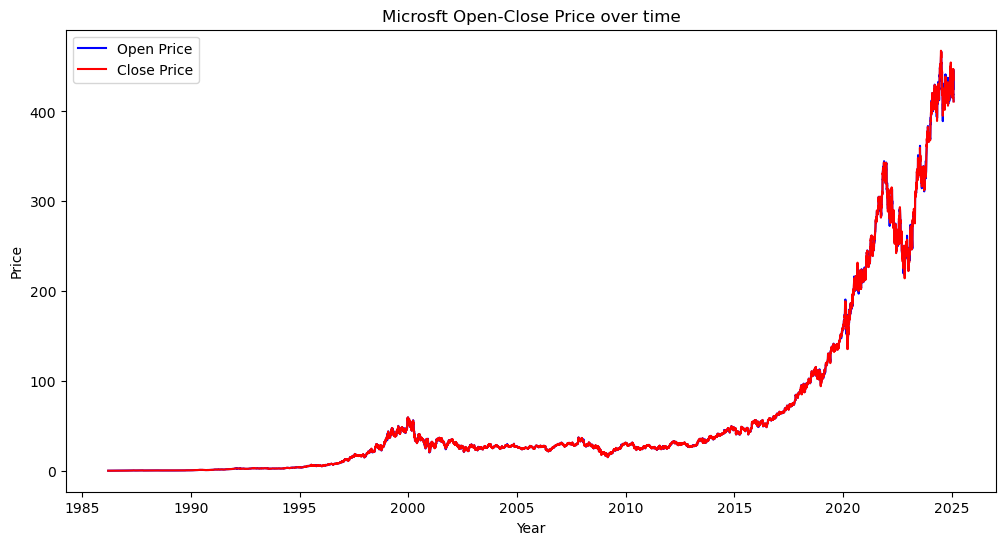

In [28]:
#visualize the closing prices to get a general idea about the stock price.
plt.figure(figsize=(12,6))
plt.plot(df['Open'], label='Open Price', color='blue')
plt.plot(df['Close'], label='Close Price', color='red')
plt.xlabel('Year')
plt.ylabel('Price')
plt.legend()
plt.title('Microsft Open-Close Price over time')
plt.show()

From the above, it can be observed the growth of Microsoft stock, starting from under a dollar and reaching a trading price of approximately $350.

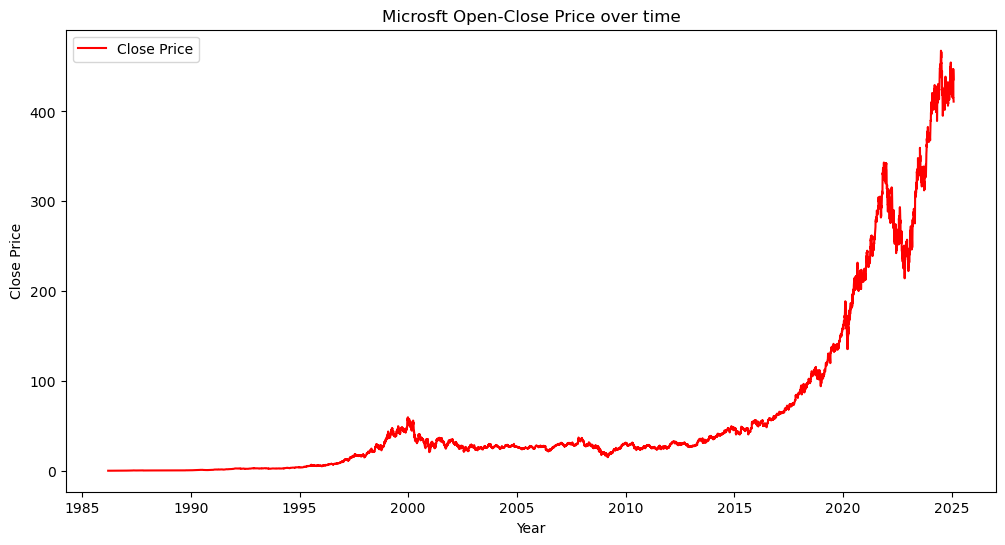

In [29]:
 #visualize the closing prices to get a general idea about the stock price.
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close Price', color='red')
plt.xlabel('Year')
plt.ylabel('Close Price')
plt.legend()
plt.title('Microsft Open-Close Price over time')
plt.show()

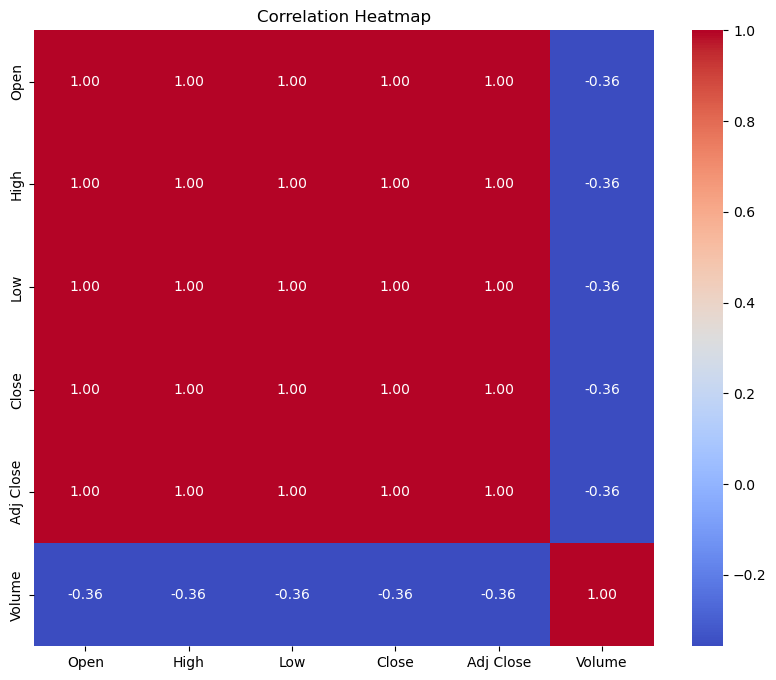

In [30]:
#Plot a heatmap of the correlation matrix for numeric columns.
numeric_data = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

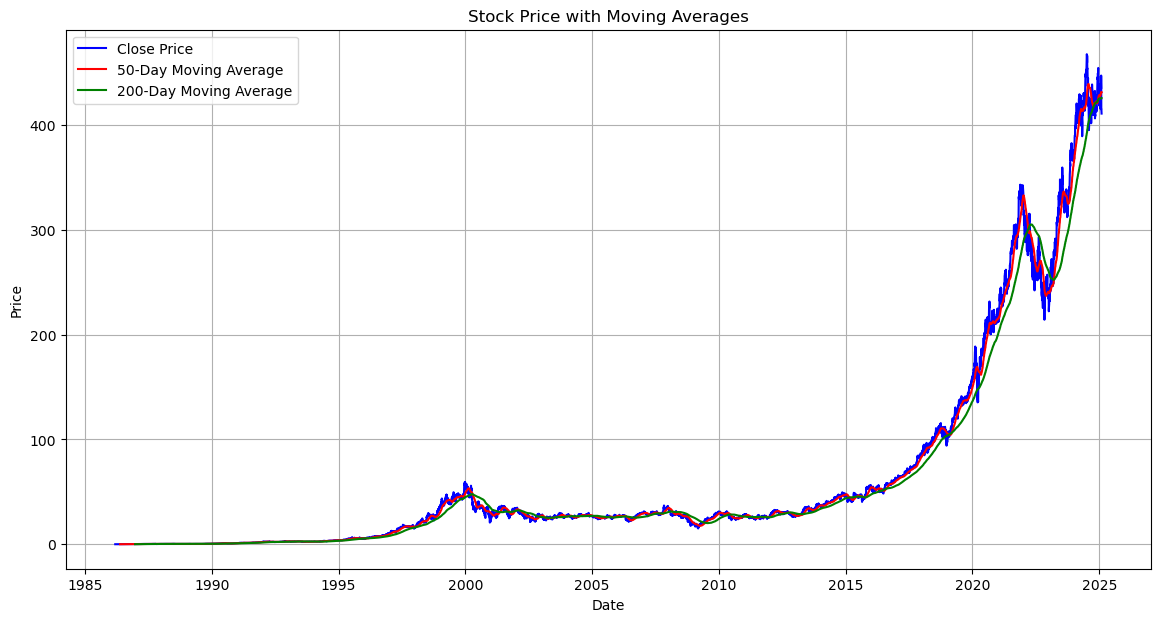

In [31]:
#Plotting Moving Averages
df['MA_Short'] = df['Close'].rolling(window=50).mean()
df['MA_Long'] = df['Close'].rolling(window=200).mean()
plt.figure(figsize=(14, 7))
plt.plot(df['Close'], label='Close Price', color='blue')
plt.plot(df['MA_Short'], label=f'{50}-Day Moving Average', color='red')
plt.plot(df['MA_Long'], label=f'{200}-Day Moving Average', color='green')
plt.title('Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

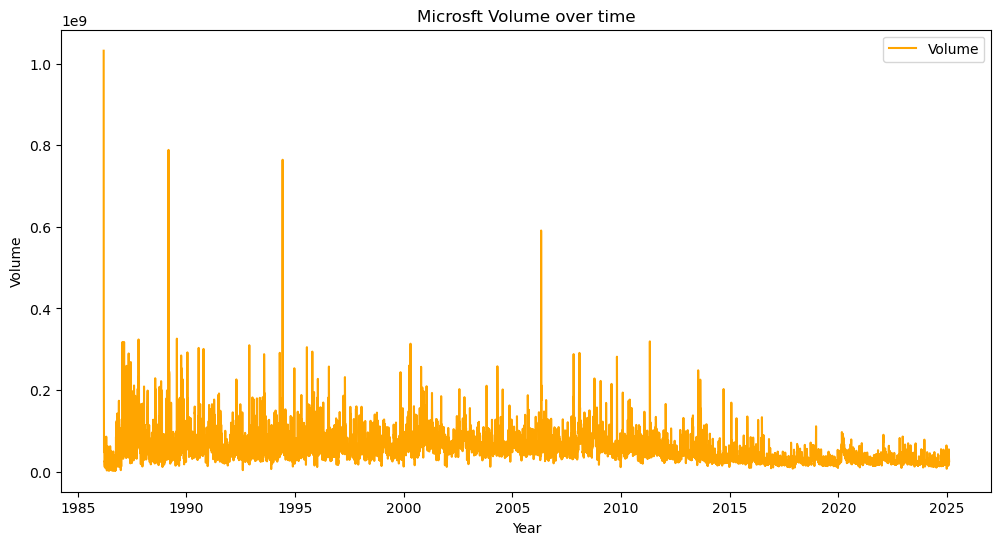

In [32]:
#visualize the closing prices to get a general idea about the stock price.
plt.figure(figsize=(12,6))
plt.plot(df['Volume'], label='Volume', color='orange')
plt.xlabel('Year')
plt.ylabel('Volume')
plt.legend()
plt.title('Microsft Volume over time')
plt.show()

By examining this chart, we can observe the remarkable growth of Microsoft stock, starting from under a dollar and reaching a trading price of approximately $300.

### Create and Scale Train data

In [33]:
stock_close=df.filter(['Close'])#create new database with only required coloumns
dataset=stock_close.values#convert the new dataframe to numpy array
training_data_len=math.ceil(len(dataset)*0.8)#Use 80 percent of the number of rows to train
training_data_len## get the number of rows for the 80% training data.

7840

Scaling the data in NN optimizes performance. Failing to scale the data can lead to subpar results. To address this, we will apply a standard scaler to the training data.

In [34]:
#scale the data
scaler=StandardScaler()#instantiate the standard scaler and use it to scale the data
scaled_data=scaler.fit_transform(dataset)#Use the he fit and transform functions on the training data, to obtain the scaled data
print("MEAN of processed data: ",scaled_data.mean())
print("Standard deviation of processed data: ",scaled_data.std())

MEAN of processed data:  0.0
Standard deviation of processed data:  1.0


The scaling process ensures that the mean and standard deviation of the data are normalized to the range of 0 to 1, which aids in the neural network's effectiveness.

In [35]:
#create a new training data from the scaled training dataset
train_data = scaled_data[0:training_data_len, :]
#split the data to x_train and y_train
x_train,y_train=[],[]
for i in range(60,len(train_data)):
  x_train.append(train_data[i-60:i,0])
  y_train.append(train_data[i,0])

#convert x_train and y_train into numpy arrays
x_train,y_train=np.array(x_train),np.array(y_train)
#x_train.shape,y_train.shape
x_train=np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))#reshape the data to 3D array

In [36]:
#reshape the data
print("x_train shape before reshaping",x_train.shape)
x_train = np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1)) #np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))
print("x_train shape after reshaping",x_train.shape)

x_train shape before reshaping (7780, 60, 1)
x_train shape after reshaping (7780, 60, 1)


### Build the Model

The sequential model is used for the neural network. The first LSTM layer added consist of 64 neurons. The input shape for this layer will correspond to the number of input neurons in X train, ensuring compatibility.

Following that, we will add another LSTM layer, also with 64 neurons, resulting in a total of two LSTM layers. This layer configuration will help capture complex patterns and dependencies in the data.

Moving on, we will incorporate single dense layers into our model. The first dense layer will comprise 128 neurons, allowing for further feature extraction and representation. Dropout is used to regularize the neural networks to prevent overfitting by randomly ignoring (setting to zero) a fraction of neurons during each training iteration.

Lastly, a dense layer of 1 is added, serving as the output layer enabling us to make predictions or classifications based on the network's learned representations.

By structuring our neural network in this manner, we aim to leverage the power of LSTM layers and dense layers to effectively capture and model the underlying patterns within our data.

In [37]:
#build LSTM model
model= Sequential()
model.add(LSTM(64,return_sequences=True,input_shape=(x_train.shape[1], 1)))
model.add(LSTM(64,return_sequences=False))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1))

2025-08-18 22:07:30.079898: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/conmec/miniconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Next, we compile the model and optimize it using the Adam optimizer, which is well-suited for a variety of deep learning tasks. Given that we are dealing with a regression problem, we will employ the mean squared error (MSE) as our loss metric. This choice aligns with our goal of minimizing the average squared difference between the predicted and actual values.


In [38]:
#compile the model
model.compile(optimizer='adam',loss='mae',
              metrics=[keras.metrics.RootMeanSquaredError()])

In [39]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

The combination of Adam optimizer and MSE loss function selection ensures that our model is optimized to minimize the error between predicted and actual values, ultimately enhancing its performance and ability to tackle regression tasks, effectively training the model to make accurate predictions.

The model summary reveals that there are 507,601 trainable parameters, indicating the adjustable elements for learning. However, there are no non-trainable parameters present in the model, meaning all parameters can be updated during the training process.

In [40]:
#train the model. this model with five epochs. You can increase the number of epochs for better performance of the model.
training = model.fit(x_train,y_train,epochs=20, batch_size=32)

Epoch 1/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - loss: 0.0940 - root_mean_squared_error: 0.1300
Epoch 2/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 0.0460 - root_mean_squared_error: 0.0622
Epoch 3/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - loss: 0.0380 - root_mean_squared_error: 0.0515
Epoch 4/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 0.0316 - root_mean_squared_error: 0.0433
Epoch 5/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 0.0265 - root_mean_squared_error: 0.0370
Epoch 6/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - loss: 0.0231 - root_mean_squared_error: 0.0325
Epoch 7/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - loss: 0.0209 - root_mean_squared_error: 0.0300
Epoch 8/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 0.0197 - root_mean_squared_error: 0.0285
Epoch 9/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 0.0205 - root_mean_squared_error: 0.0294
Epoch 10/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 0.0203 - r

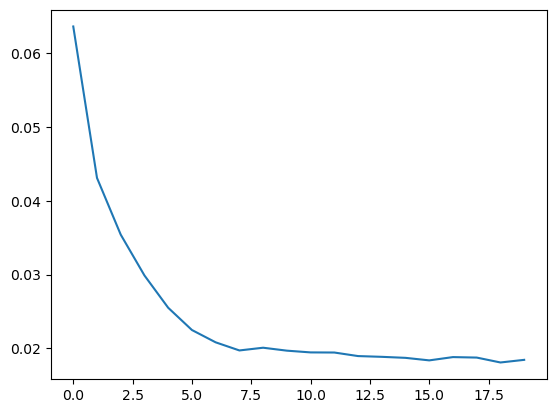

In [41]:
#plot the history of loss.
plt.plot(training.history['loss'])

The loss on the chart consistently decreased with each epoch, indicating a steady improvement in the model's performance over time.

Create Test data from Scaled Train data

In [42]:
#create the testing dataset
#create new array. 
# test data is equal to scale data of training data length -60 including all columns.
test_data=scaled_data[training_data_len-60:, :]
#create the dataset x_test and y_test
x_test=[]
y_test=dataset[training_data_len:, :]
for i in range(60,len(test_data)):
  x_test.append(test_data[i-60:i, 0])

In [43]:
#convert the data to numpy
x_test=np.array(x_test)

In [44]:
#reshape the data
x_test=np.reshape(x_test,(x_test.shape[0],x_test.shape[1],1))

Model Predictions

In [45]:
#get the models predicted value. 
# check the predictions on X test
predictions =model.predict(x_test)
predictions=scaler.inverse_transform(predictions)
print(predictions)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
[[ 66.61957]
 [ 66.44681]
 [ 66.60276]
 ...
 [391.0008 ]
 [376.7882 ]
 [365.44092]]


These predictions represent the Microsoft stock prices generated by the LSTM model using the X test data.

In [46]:
train = stock_close[:training_data_len]
test = stock_close[training_data_len:]
test = test.copy()
test['Predictions'] = predictions

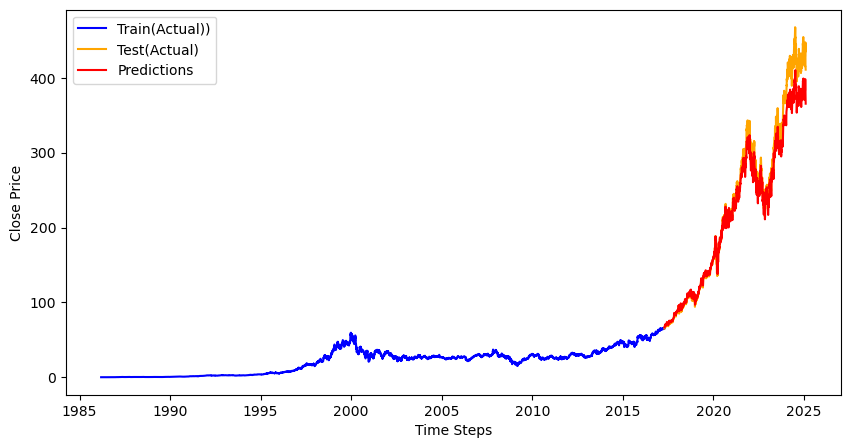

In [47]:
#predicted_price = pd.DataFrame(predictions, columns = ['price'] )
#predicted_price.head()

#Plot the predicted price of microsoft stock
#predicted_price.plot(figsize=(10,5))
plt.figure(figsize=(10,5))
plt.plot(train['Close'], label='Train(Actual))', color='blue')
plt.plot(test['Close'], label='Test(Actual)', color='orange')
plt.plot(test['Predictions'], label='Predictions', color='red')
plt.legend()
plt.ylabel("Close Price")
plt.xlabel("Time Steps")
plt.show()

From the chart, we observe that the predicted trajectory- price of Microsoft stock initiated at $45 and is projected to gradually ascend, surpassing 250 at its peak before experiencing a decline. This prediction suggests a positive trend in the stock's value over the given time period. It indicates potential growth opportunities for investors, reaching a substantial price level before a subsequent downturn. The above project aids in decision-making and assessing investment strategies.